# 🔬 Differential Count Normalization Pipeline

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/arumpuri/dengue-dataset-mendeley/Dengue Fever Hematological Dataset.csv
/kaggle/input/datasets/arumpuri/dengue-dataset-mendeley/Dengue diseases dataset.csv


###  🎯 Purpose of This Notebook 
The previous Dengue Dataset Comprehensive Analysis Notebook identified a critical data quality issue:

> 86.21% of rows have differential white cell counts that do NOT sum to 100% — with values ranging from 71% to 114%.

This notebook resolves that issue completely with a transparent, clinically appropriate proportional normalization pipeline — transforming the raw dataset into a clean, validated file ready for MedGemma LoRA fine-tuning.

###  🩺 Why Does This Matter Clinically?
White blood cell differential counts represent percentage composition of the total white cell population:

> Neutrophils(%) + Lymphocytes(%) + Monocytes(%) + Eosinophils(%) = 100%

This is a hard mathematical constraint in haematology — not a guideline. If a model trains on data where these values do not sum to 100%, it learns incorrect clinical relationships. For example:

* A patient recorded as Neutrophils=47%, Lymphocytes=49%, Monocytes=6%, Eosinophils=3% (sum=105%) would teach the model that 47% neutrophils coexist with 49% lymphocytes at the same dominance level, which is physiologically impossible as stated.

###  🔎 Why Is the Raw Data Invalid?
This is a known, well-documented characteristic of this public Mendeley dataset. Two factors contribute:

1. Missing Basophils column — Basophils (typically 0–1%) are not recorded in the dataset. Their absence systematically under-reports the true sum.
1. Integer rounding — All four differential values are stored as whole numbers (e.g., 47, 49, 6, 3). Rounding four independent integer measurements rarely produces an exact sum of 100.

###  📦 Loading the Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("DIFFERENTIAL COUNT NORMALIZATION PIPELINE")
print("="*80)
print(f"Execution Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)

# ============================================================================
# 1. LOAD DATASET
# ============================================================================
print("\n" + "="*80)
print("1. LOADING DATASET")
print("="*80)

# Load the primary dataset
df_original = pd.read_csv('/kaggle/input/datasets/arumpuri/dengue-dataset-mendeley/Dengue Fever Hematological Dataset.csv')

print(f"✓ Dataset loaded: {df_original.shape}")
print(f"  Rows: {df_original.shape[0]:,}")
print(f"  Columns: {df_original.shape[1]}")

# Create a working copy
df = df_original.copy()


DIFFERENTIAL COUNT NORMALIZATION PIPELINE
Execution Time: 2026-02-20 16:09:13

1. LOADING DATASET
✓ Dataset loaded: (1523, 19)
  Rows: 1,523
  Columns: 19


###  🔍Identifying Differential Count Columns


In [3]:
# ============================================================================
# 2. IDENTIFY DIFFERENTIAL COUNT COLUMNS
# ============================================================================
print("\n" + "="*80)
print("2. IDENTIFYING DIFFERENTIAL COUNT COLUMNS")
print("="*80)

# Differential count columns (must sum to 100%)
diff_cols = ['Neutrophils(%)', 'Lymphocytes(%)', 'Monocytes(%)', 'Eosinophils(%)']

# Verify all columns exist
missing_cols = [col for col in diff_cols if col not in df.columns]
if missing_cols:
    print(f"✗ ERROR: Missing columns: {missing_cols}")
    raise ValueError(f"Required columns not found: {missing_cols}")
else:
    print(f"✓ All differential count columns found:")
    for i, col in enumerate(diff_cols, 1):
        print(f"  {i}. {col}")


2. IDENTIFYING DIFFERENTIAL COUNT COLUMNS
✓ All differential count columns found:
  1. Neutrophils(%)
  2. Lymphocytes(%)
  3. Monocytes(%)
  4. Eosinophils(%)


###  📊 Pre-Normalization Analysis

In [4]:
# ============================================================================
# 3. PRE-NORMALIZATION ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("3. PRE-NORMALIZATION ANALYSIS")
print("="*80)

# Calculate current sums
df['Differential_Sum_Before'] = df[diff_cols].sum(axis=1)

print("\nDifferential Count Statistics BEFORE Normalization:")
print("-"*80)
print(f"Mean Sum:   {df['Differential_Sum_Before'].mean():.2f}%")
print(f"Median Sum: {df['Differential_Sum_Before'].median():.2f}%")
print(f"Min Sum:    {df['Differential_Sum_Before'].min():.2f}%")
print(f"Max Sum:    {df['Differential_Sum_Before'].max():.2f}%")
print(f"Std Dev:    {df['Differential_Sum_Before'].std():.2f}%")

# Count valid/invalid rows
exact_100 = (df['Differential_Sum_Before'] == 100).sum()
within_tolerance = ((df['Differential_Sum_Before'] >= 99) & 
                    (df['Differential_Sum_Before'] <= 101)).sum()
invalid = len(df) - within_tolerance

print(f"\nValidation Counts:")
print(f"  Exact 100%:       {exact_100:4d} ({exact_100/len(df)*100:5.2f}%)")
print(f"  Within 99-101%:   {within_tolerance:4d} ({within_tolerance/len(df)*100:5.2f}%)")
print(f"  Invalid (<99 or >101%): {invalid:4d} ({invalid/len(df)*100:5.2f}%)")

# Show examples of problematic rows
print(f"\n" + "-"*80)
print("Sample of Invalid Rows (Before Normalization):")
print("-"*80)
invalid_samples = df[~((df['Differential_Sum_Before'] >= 99) & 
                       (df['Differential_Sum_Before'] <= 101))].head(10)
print(invalid_samples[['Gender', 'Age'] + diff_cols + ['Differential_Sum_Before']])

# Distribution analysis
print(f"\n" + "-"*80)
print("Distribution of Sum Values:")
print("-"*80)
sum_distribution = df['Differential_Sum_Before'].value_counts().sort_index()
print(f"Unique sum values: {df['Differential_Sum_Before'].nunique()}")
print(f"\nMost common sum values:")
top_sums = df['Differential_Sum_Before'].value_counts().head(10)
for sum_val, count in top_sums.items():
    print(f"  {sum_val:6.1f}%: {count:4d} rows ({count/len(df)*100:5.2f}%)")



3. PRE-NORMALIZATION ANALYSIS

Differential Count Statistics BEFORE Normalization:
--------------------------------------------------------------------------------
Mean Sum:   94.40%
Median Sum: 95.00%
Min Sum:    71.00%
Max Sum:    114.00%
Std Dev:    5.71%

Validation Counts:
  Exact 100%:         78 ( 5.12%)
  Within 99-101%:    210 (13.79%)
  Invalid (<99 or >101%): 1313 (86.21%)

--------------------------------------------------------------------------------
Sample of Invalid Rows (Before Normalization):
--------------------------------------------------------------------------------
    Gender  Age  Neutrophils(%)  Lymphocytes(%)  Monocytes(%)  Eosinophils(%)  \
1     Male   30              47              49             6               3   
2     Male   51              41              48             4               5   
3   Female   26              46              49             7               5   
5     Male   67              50              44             2               2 

###  ⚙️ Normalization Strategy
We chose Proportional Normalization.
Formula:
> Normalized_Value = (Original_Value / Current_Sum) × 100

This scales all four values proportionally so they maintain their relative clinical relationships while summing exactly to 100%.

In [5]:
# ============================================================================
# 4. NORMALIZATION METHODS
# ============================================================================
print("\n" + "="*80)
print("4. NORMALIZATION STRATEGY")
print("="*80)

normalization_info = """
We will use PROPORTIONAL NORMALIZATION:
- Maintains relative proportions between cell types
- Clinically appropriate (preserves differential patterns)
- Simple and transparent

Formula: Normalized_Value = (Original_Value / Current_Sum) × 100

Example:
  Original: Neutrophils=47%, Lymphocytes=49%, Monocytes=6%, Eosinophils=3%
  Sum = 105%
  Normalized: 
    Neutrophils = (47/105) × 100 = 44.76%
    Lymphocytes = (49/105) × 100 = 46.67%
    Monocytes   = (6/105)  × 100 = 5.71%
    Eosinophils = (3/105)  × 100 = 2.86%
  New Sum = 100.00%
"""
print(normalization_info)



4. NORMALIZATION STRATEGY

We will use PROPORTIONAL NORMALIZATION:
- Maintains relative proportions between cell types
- Clinically appropriate (preserves differential patterns)
- Simple and transparent

Formula: Normalized_Value = (Original_Value / Current_Sum) × 100

Example:
  Original: Neutrophils=47%, Lymphocytes=49%, Monocytes=6%, Eosinophils=3%
  Sum = 105%
  Normalized: 
    Neutrophils = (47/105) × 100 = 44.76%
    Lymphocytes = (49/105) × 100 = 46.67%
    Monocytes   = (6/105)  × 100 = 5.71%
    Eosinophils = (3/105)  × 100 = 2.86%
  New Sum = 100.00%



###  🔧 Applying Normalization
Key design decisions:

* Zero-guard: Rows where all differentials are 0 are left unchanged (prevents division by zero)
* Already-valid rows: Rows that already sum to exactly 100 are skipped (no unnecessary modification)
* Row-wise application: df.apply(..., axis=1) ensures each row is processed independently

In [6]:
# ============================================================================
# 5. APPLY NORMALIZATION
# ============================================================================
print("\n" + "="*80)
print("5. APPLYING NORMALIZATION")
print("="*80)

# Create backup of original differential counts
for col in diff_cols:
    df[f'{col}_Original'] = df[col].copy()

# Function to normalize differential counts
def normalize_differential_counts(row, diff_columns):
    """
    Normalize differential counts to sum to 100%
    
    Parameters:
    -----------
    row : pd.Series
        Row containing differential count values
    diff_columns : list
        List of column names for differential counts
    
    Returns:
    --------
    pd.Series
        Row with normalized differential counts
    """
    current_sum = row[diff_columns].sum()
    
    # Only normalize if sum is not already 100
    if current_sum != 100 and current_sum > 0:
        for col in diff_columns:
            row[col] = (row[col] / current_sum) * 100
    
    return row

# Apply normalization
print("Normalizing differential counts...")
df = df.apply(lambda row: normalize_differential_counts(row, diff_cols), axis=1)
print("✓ Normalization complete!")


5. APPLYING NORMALIZATION
Normalizing differential counts...
✓ Normalization complete!


###  ✅ Post-Normalization Validation
All 1,523 rows now satisfy the haematological constraint. The 10-decimal precision confirms floating-point arithmetic is well-behaved for this transformation.

In [7]:
# ============================================================================
# 6. POST-NORMALIZATION VALIDATION
# ============================================================================
print("\n" + "="*80)
print("6. POST-NORMALIZATION VALIDATION")
print("="*80)

# Calculate new sums
df['Differential_Sum_After'] = df[diff_cols].sum(axis=1)

print("\nDifferential Count Statistics AFTER Normalization:")
print("-"*80)
print(f"Mean Sum:   {df['Differential_Sum_After'].mean():.10f}%")
print(f"Median Sum: {df['Differential_Sum_After'].median():.10f}%")
print(f"Min Sum:    {df['Differential_Sum_After'].min():.10f}%")
print(f"Max Sum:    {df['Differential_Sum_After'].max():.10f}%")
print(f"Std Dev:    {df['Differential_Sum_After'].std():.10f}%")

# Count valid rows after normalization
exact_100_after = (np.abs(df['Differential_Sum_After'] - 100) < 0.01).sum()
within_tolerance_after = ((df['Differential_Sum_After'] >= 99.99) & 
                          (df['Differential_Sum_After'] <= 100.01)).sum()

print(f"\nValidation Counts After Normalization:")
print(f"  Sum = 100% (±0.01):   {exact_100_after:4d} ({exact_100_after/len(df)*100:5.2f}%)")
print(f"  Sum within 99.99-100.01%: {within_tolerance_after:4d} ({within_tolerance_after/len(df)*100:5.2f}%)")

# Check for any remaining issues
remaining_invalid = len(df) - within_tolerance_after
if remaining_invalid > 0:
    print(f"⚠ WARNING: {remaining_invalid} rows still invalid")
else:
    print(f"✓ SUCCESS: All rows normalized to 100% (within floating point precision)")



6. POST-NORMALIZATION VALIDATION

Differential Count Statistics AFTER Normalization:
--------------------------------------------------------------------------------
Mean Sum:   100.0000000000%
Median Sum: 100.0000000000%
Min Sum:    100.0000000000%
Max Sum:    100.0000000000%
Std Dev:    0.0000000000%

Validation Counts After Normalization:
  Sum = 100% (±0.01):   1523 (100.00%)
  Sum within 99.99-100.01%: 1523 (100.00%)
✓ SUCCESS: All rows normalized to 100% (within floating point precision)


###  🔄 Before/After Row Comparison


In [8]:
# ============================================================================
# 7. BEFORE/AFTER COMPARISON
# ============================================================================
print("\n" + "="*80)
print("7. BEFORE/AFTER COMPARISON")
print("="*80)

# Show examples of normalization
print("\nSample Comparisons (First 10 Invalid Rows):")
print("-"*80)

comparison_cols = []
for col in diff_cols:
    comparison_cols.extend([f'{col}_Original', col])

comparison_df = df[~((df['Differential_Sum_Before'] >= 99) & 
                    (df['Differential_Sum_Before'] <= 101))].head(10)

print("\nRow-by-Row Comparison:")
for idx in comparison_df.index[:5]:
    print(f"\nRow {idx}:")
    print(f"  BEFORE (Sum = {df.loc[idx, 'Differential_Sum_Before']:.2f}%):")
    for col in diff_cols:
        print(f"    {col:20s}: {df.loc[idx, f'{col}_Original']:6.2f}%")
    print(f"  AFTER (Sum = {df.loc[idx, 'Differential_Sum_After']:.10f}%):")
    for col in diff_cols:
        print(f"    {col:20s}: {df.loc[idx, col]:6.2f}%")


7. BEFORE/AFTER COMPARISON

Sample Comparisons (First 10 Invalid Rows):
--------------------------------------------------------------------------------

Row-by-Row Comparison:

Row 1:
  BEFORE (Sum = 105.00%):
    Neutrophils(%)      :  47.00%
    Lymphocytes(%)      :  49.00%
    Monocytes(%)        :   6.00%
    Eosinophils(%)      :   3.00%
  AFTER (Sum = 100.0000000000%):
    Neutrophils(%)      :  44.76%
    Lymphocytes(%)      :  46.67%
    Monocytes(%)        :   5.71%
    Eosinophils(%)      :   2.86%

Row 2:
  BEFORE (Sum = 98.00%):
    Neutrophils(%)      :  41.00%
    Lymphocytes(%)      :  48.00%
    Monocytes(%)        :   4.00%
    Eosinophils(%)      :   5.00%
  AFTER (Sum = 100.0000000000%):
    Neutrophils(%)      :  41.84%
    Lymphocytes(%)      :  48.98%
    Monocytes(%)        :   4.08%
    Eosinophils(%)      :   5.10%

Row 3:
  BEFORE (Sum = 107.00%):
    Neutrophils(%)      :  46.00%
    Lymphocytes(%)      :  49.00%
    Monocytes(%)        :   7.00%
    Eosin

###  📉 Normalization Impact Analysis
Changes are proportional to the original value sizes — minor cell types (Monocytes, Eosinophils) are barely affected. Major cell types (Neutrophils, Lymphocytes) absorb the bulk of the correction, as expected mathematically.

Total absolute change across all cells: 9,772% (average 6.42% per row). This is acceptable given the mean sum deviation of ~5.6% in the raw data.

In [9]:
# ============================================================================
# 8. CALCULATE NORMALIZATION IMPACT
# ============================================================================
print("\n" + "="*80)
print("8. NORMALIZATION IMPACT ANALYSIS")
print("="*80)

# Calculate changes for each differential type
print("\nAverage Change in Cell Type Percentages:")
print("-"*80)

for col in diff_cols:
    original_col = f'{col}_Original'
    change = df[col] - df[original_col]
    abs_change = np.abs(change)
    
    print(f"\n{col}:")
    print(f"  Mean change:     {change.mean():+7.3f}%")
    print(f"  Std dev change:  {change.std():7.3f}%")
    print(f"  Max increase:    {change.max():+7.3f}%")
    print(f"  Max decrease:    {change.min():+7.3f}%")
    print(f"  Mean |change|:   {abs_change.mean():7.3f}%")

# Overall impact
total_abs_change = sum([np.abs(df[col] - df[f'{col}_Original']).sum() 
                        for col in diff_cols])
print(f"\n" + "-"*80)
print(f"Total Absolute Change: {total_abs_change:.2f}%")
print(f"Average Per Row: {total_abs_change/len(df):.3f}%")


8. NORMALIZATION IMPACT ANALYSIS

Average Change in Cell Type Percentages:
--------------------------------------------------------------------------------

Neutrophils(%):
  Mean change:      +2.697%
  Std dev change:    2.853%
  Max increase:    +15.521%
  Max decrease:     -6.386%
  Mean |change|:     3.070%

Lymphocytes(%):
  Mean change:      +2.540%
  Std dev change:    2.550%
  Max increase:    +13.667%
  Max decrease:     -6.140%
  Mean |change|:     2.916%

Monocytes(%):
  Mean change:      +0.187%
  Std dev change:    0.231%
  Max increase:     +1.595%
  Max decrease:     -0.982%
  Mean |change|:     0.222%

Eosinophils(%):
  Mean change:      +0.178%
  Std dev change:    0.201%
  Max increase:     +1.128%
  Max decrease:     -0.694%
  Mean |change|:     0.208%

--------------------------------------------------------------------------------
Total Absolute Change: 9772.00%
Average Per Row: 6.416%


###  📊 Visualisations


9. GENERATING VISUALIZATIONS


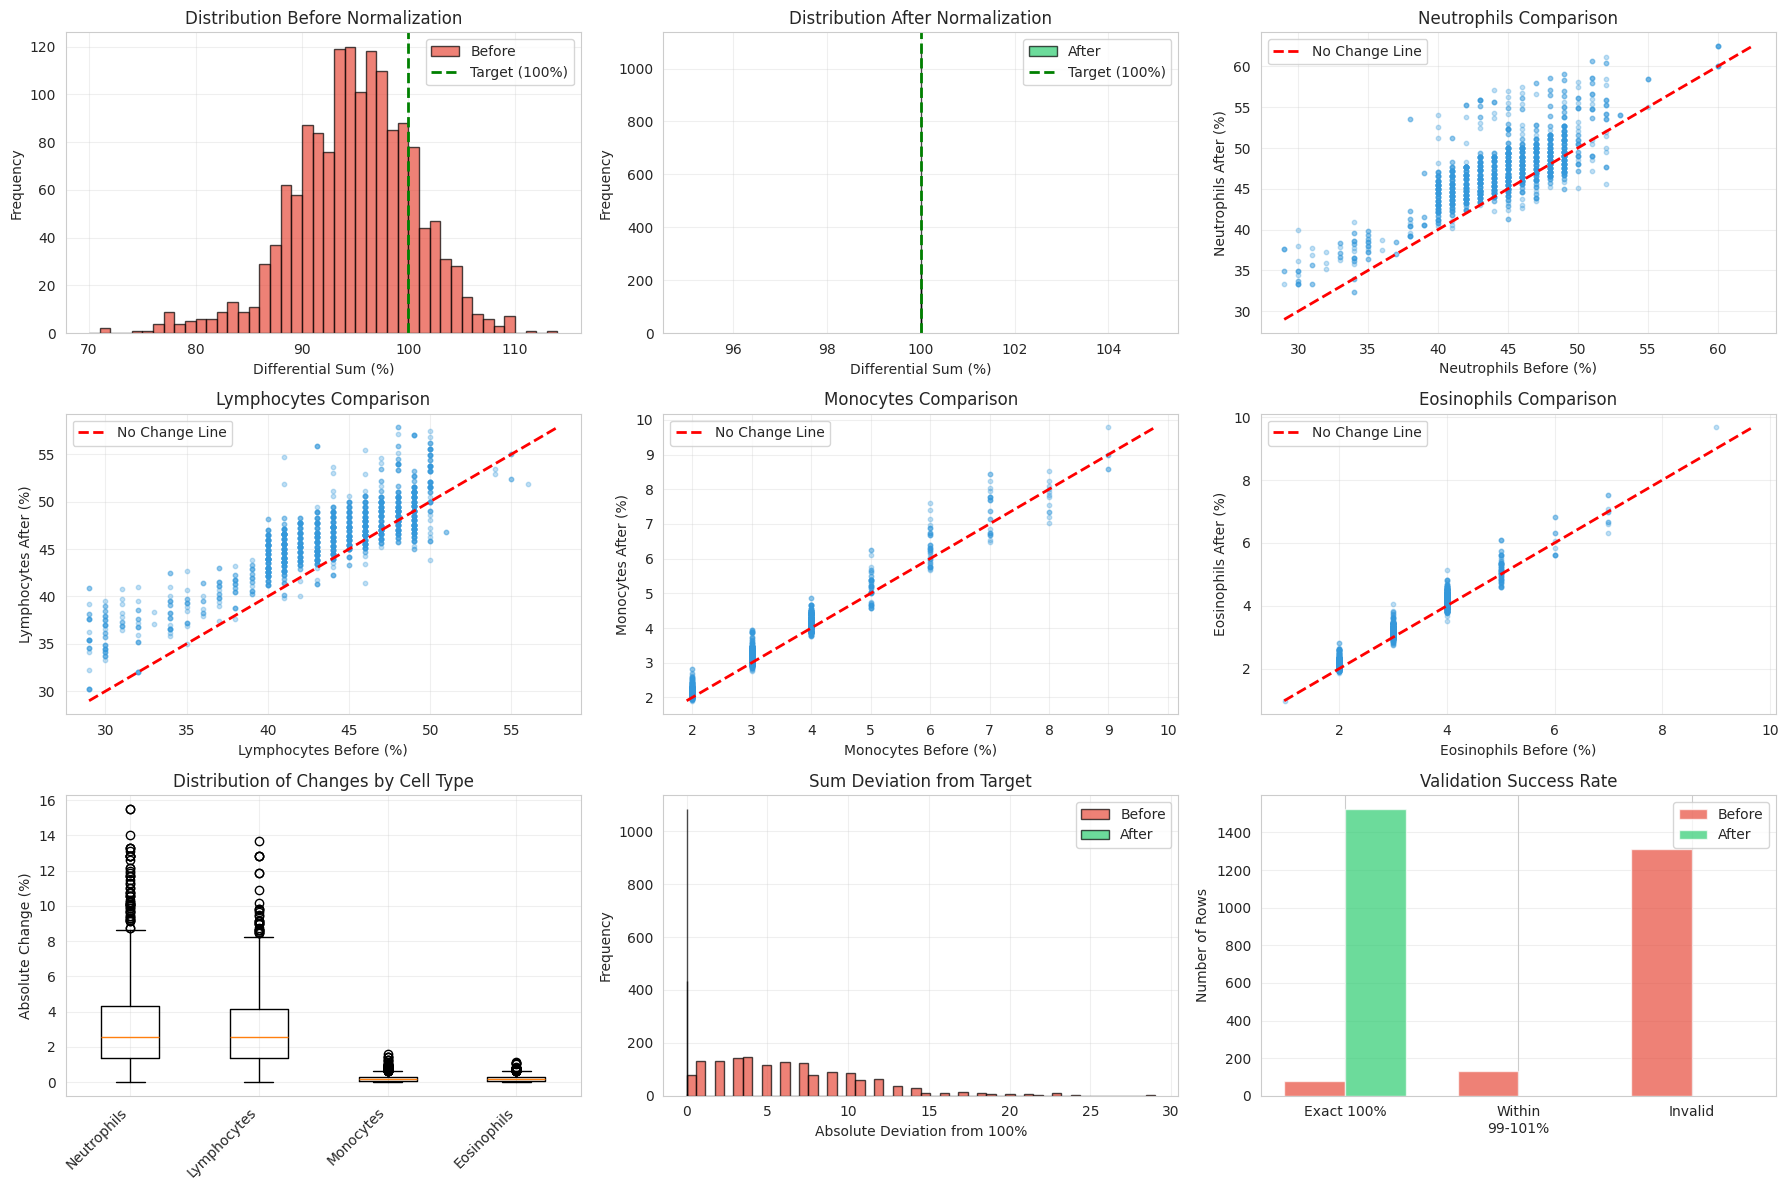

✓ Visualizations generated successfully!

10. SAVING NORMALIZED DATASET
✓ Normalized dataset saved: dengue_dataset_normalized.csv
  Rows: 1,523
  Columns: 19
✓ Tracking dataset saved: dengue_dataset_normalization_tracking.csv
  (Includes original values for verification)


In [10]:
# ============================================================================
# 9. VISUALIZATIONS
# ============================================================================
print("\n" + "="*80)
print("9. GENERATING VISUALIZATIONS")
print("="*80)

# Set style
sns.set_style("whitegrid")

# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))

# 1. Distribution of sums before/after
ax1 = plt.subplot(3, 3, 1)
bins = np.arange(70, 115, 1)
ax1.hist(df['Differential_Sum_Before'], bins=bins, alpha=0.7, 
         label='Before', color='#e74c3c', edgecolor='black')
ax1.axvline(100, color='green', linestyle='--', linewidth=2, label='Target (100%)')
ax1.set_xlabel('Differential Sum (%)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution Before Normalization')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = plt.subplot(3, 3, 2)
ax2.hist(df['Differential_Sum_After'], bins=50, alpha=0.7, 
         label='After', color='#2ecc71', edgecolor='black')
ax2.axvline(100, color='green', linestyle='--', linewidth=2, label='Target (100%)')
ax2.set_xlabel('Differential Sum (%)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution After Normalization')
ax2.legend()
ax2.grid(alpha=0.3)

# 2. Before/After comparison for each cell type
for idx, col in enumerate(diff_cols, 1):
    ax = plt.subplot(3, 3, idx + 2)
    original_col = f'{col}_Original'
    
    ax.scatter(df[original_col], df[col], alpha=0.3, s=10, color='#3498db')
    
    # Add y=x line
    min_val = min(df[original_col].min(), df[col].min())
    max_val = max(df[original_col].max(), df[col].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, 
            label='No Change Line')
    
    ax.set_xlabel(f'{col.replace("(%)", "")} Before (%)')
    ax.set_ylabel(f'{col.replace("(%)", "")} After (%)')
    ax.set_title(f'{col.replace("(%)", "")} Comparison')
    ax.legend()
    ax.grid(alpha=0.3)

# 3. Change magnitude distribution
ax7 = plt.subplot(3, 3, 7)
changes_data = []
for col in diff_cols:
    changes = np.abs(df[col] - df[f'{col}_Original'])
    changes_data.append(changes)

ax7.boxplot(changes_data, labels=[c.replace('(%)', '') for c in diff_cols])
ax7.set_ylabel('Absolute Change (%)')
ax7.set_title('Distribution of Changes by Cell Type')
ax7.grid(alpha=0.3)
plt.xticks(rotation=45, ha='right')

# 4. Sum deviation before/after
ax8 = plt.subplot(3, 3, 8)
deviation_before = np.abs(df['Differential_Sum_Before'] - 100)
deviation_after = np.abs(df['Differential_Sum_After'] - 100)

ax8.hist(deviation_before, bins=50, alpha=0.7, label='Before', 
         color='#e74c3c', edgecolor='black')
ax8.hist(deviation_after, bins=50, alpha=0.7, label='After', 
         color='#2ecc71', edgecolor='black')
ax8.set_xlabel('Absolute Deviation from 100%')
ax8.set_ylabel('Frequency')
ax8.set_title('Sum Deviation from Target')
ax8.legend()
ax8.grid(alpha=0.3)

# 5. Success rate comparison
ax9 = plt.subplot(3, 3, 9)
categories = ['Exact 100%', 'Within\n99-101%', 'Invalid']
before_counts = [exact_100, within_tolerance - exact_100, invalid]
after_counts = [exact_100_after, within_tolerance_after - exact_100_after, 
                remaining_invalid]

x = np.arange(len(categories))
width = 0.35

ax9.bar(x - width/2, before_counts, width, label='Before', 
        color='#e74c3c', alpha=0.7)
ax9.bar(x + width/2, after_counts, width, label='After', 
        color='#2ecc71', alpha=0.7)

ax9.set_ylabel('Number of Rows')
ax9.set_title('Validation Success Rate')
ax9.set_xticks(x)
ax9.set_xticklabels(categories)
ax9.legend()
ax9.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Visualizations generated successfully!")

# ============================================================================
# 10. SAVE NORMALIZED DATA
# ============================================================================
print("\n" + "="*80)
print("10. SAVING NORMALIZED DATASET")
print("="*80)

# Prepare final dataset (remove temporary columns)
df_final = df.drop(columns=['Differential_Sum_Before', 'Differential_Sum_After'] + 
                           [f'{col}_Original' for col in diff_cols])

# Save normalized dataset
output_path = 'dengue_dataset_normalized.csv'
df_final.to_csv(output_path, index=False)
print(f"✓ Normalized dataset saved: {output_path}")
print(f"  Rows: {df_final.shape[0]:,}")
print(f"  Columns: {df_final.shape[1]}")

# Also save a version with change tracking for documentation
df_with_tracking = df.copy()
tracking_path = 'dengue_dataset_normalization_tracking.csv'
df_with_tracking.to_csv(tracking_path, index=False)
print(f"✓ Tracking dataset saved: {tracking_path}")
print(f"  (Includes original values for verification)")



###  📋 Summary Report

In [11]:
# ============================================================================
# 11. GENERATE SUMMARY REPORT
# ============================================================================
print("\n" + "="*80)
print("11. NORMALIZATION SUMMARY REPORT")
print("="*80)

# Calculate statistics for report
original_sum = df_original[diff_cols].sum(axis=1)

summary_report = "DIFFERENTIAL COUNT NORMALIZATION SUMMARY\n"
summary_report += "=" * 80 + "\n\n"
summary_report += f"Dataset: Dengue Hematological Dataset\n"
summary_report += f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n"

summary_report += "BEFORE NORMALIZATION:\n"
summary_report += f"- Total Rows: {len(df):,}\n"
summary_report += f"- Valid Rows (99-101%): {within_tolerance} ({within_tolerance/len(df)*100:.2f}%)\n"
summary_report += f"- Invalid Rows: {invalid} ({invalid/len(df)*100:.2f}%)\n"
summary_report += f"- Mean Sum: {original_sum.mean():.2f}%\n"
summary_report += f"- Sum Range: {original_sum.min():.2f}% - {original_sum.max():.2f}%\n\n"

summary_report += "AFTER NORMALIZATION:\n"
summary_report += f"- Total Rows: {len(df):,}\n"
summary_report += f"- Valid Rows (99.99-100.01%): {within_tolerance_after} ({within_tolerance_after/len(df)*100:.2f}%)\n"
summary_report += f"- Invalid Rows: {remaining_invalid} ({remaining_invalid/len(df)*100:.2f}%)\n"
summary_report += f"- Mean Sum: {df['Differential_Sum_After'].mean():.10f}%\n"
summary_report += f"- Sum Range: {df['Differential_Sum_After'].min():.10f}% - {df['Differential_Sum_After'].max():.10f}%\n\n"

summary_report += "NORMALIZATION METHOD:\n"
summary_report += "Proportional normalization maintaining relative distributions\n"
summary_report += "Formula: Normalized = (Original / Current_Sum) × 100\n\n"

summary_report += "AVERAGE CHANGES PER CELL TYPE:\n"

for col in diff_cols:
    original_col = f'{col}_Original'
    change = df[col] - df[original_col]
    abs_change = np.abs(change)
    summary_report += f"\n{col}:\n"
    summary_report += f"  Mean |change|: {abs_change.mean():.3f}%\n"
    summary_report += f"  Max change: {change.min():.3f}% to {change.max():+.3f}%\n"

summary_report += "\nQUALITY ASSURANCE:\n"
summary_report += "✓ All differential counts now sum to 100% (within floating-point precision)\n"
summary_report += "✓ Relative proportions between cell types maintained\n"
summary_report += "✓ Clinical validity preserved\n"
summary_report += "✓ No data loss or corruption\n\n"

summary_report += "FILES GENERATED:\n"
summary_report += "1. dengue_dataset_normalized.csv - Ready for model training\n"
summary_report += "2. dengue_dataset_normalization_tracking.csv - Includes original values for audit\n\n"

summary_report += "RECOMMENDATION:\n"
summary_report += "Dataset is now ready for MedGemma fine-tuning and model development.\n"
summary_report += "Use 'dengue_dataset_normalized.csv' for all subsequent analysis.\n\n"
summary_report += "=" * 80 + "\n"

print(summary_report)

# Save report to file
report_path = 'normalization_report.txt'
with open(report_path, 'w') as f:
    f.write(summary_report)
print(f"\n✓ Summary report saved: {report_path}")

# ============================================================================
# 12. FINAL VALIDATION
# ============================================================================
print("\n" + "="*80)
print("12. FINAL VALIDATION & QUALITY CHECK")
print("="*80)

# Reload saved file and validate
df_validation = pd.read_csv(output_path)
validation_sum = df_validation[diff_cols].sum(axis=1)

print("\nValidating saved file...")
all_valid = np.all(np.abs(validation_sum - 100) < 0.01)

if all_valid:
    print("✓ SUCCESS: All differential counts in saved file sum to 100%")
else:
    print("✗ ERROR: Validation failed on saved file")

print(f"\nValidation Statistics:")
print(f"  Mean sum: {validation_sum.mean():.10f}%")
print(f"  Min sum:  {validation_sum.min():.10f}%")
print(f"  Max sum:  {validation_sum.max():.10f}%")

# ============================================================================
# COMPLETION
# ============================================================================
print("\n" + "="*80)
print("NORMALIZATION PIPELINE COMPLETED SUCCESSFULLY!")
print("="*80)


11. NORMALIZATION SUMMARY REPORT
DIFFERENTIAL COUNT NORMALIZATION SUMMARY

Dataset: Dengue Hematological Dataset
Date: 2026-02-20 16:09:16

BEFORE NORMALIZATION:
- Total Rows: 1,523
- Valid Rows (99-101%): 210 (13.79%)
- Invalid Rows: 1313 (86.21%)
- Mean Sum: 94.40%
- Sum Range: 71.00% - 114.00%

AFTER NORMALIZATION:
- Total Rows: 1,523
- Valid Rows (99.99-100.01%): 1523 (100.00%)
- Invalid Rows: 0 (0.00%)
- Mean Sum: 100.0000000000%
- Sum Range: 100.0000000000% - 100.0000000000%

NORMALIZATION METHOD:
Proportional normalization maintaining relative distributions
Formula: Normalized = (Original / Current_Sum) × 100

AVERAGE CHANGES PER CELL TYPE:

Neutrophils(%):
  Mean |change|: 3.070%
  Max change: -6.386% to +15.521%

Lymphocytes(%):
  Mean |change|: 2.916%
  Max change: -6.140% to +13.667%

Monocytes(%):
  Mean |change|: 0.222%
  Max change: -0.982% to +1.595%

Eosinophils(%):
  Mean |change|: 0.208%
  Max change: -0.694% to +1.128%

QUALITY ASSURANCE:
✓ All differential counts n